## Bad Debt Prediction

### Load the datasets

In [4]:
import pandas as pd
import numpy as np

In [5]:
# loading the datasets:

def load_data():
    print("Loading datasets....")

    data_df = pd.read_excel("Data.xlsm",sheet_name="DataV2")
    additional_df = pd.read_excel("Additional Info.xlsx",sheet_name="Additional info")

    print("Datasets loaded successfully !")

    print(f"\n Data dataset")
    print(data_df.head())

    print(f"\n Additional Dataset")
    print(additional_df.head())
    return data_df, additional_df

### Merging the datasets

In [6]:
def merge_data(data_df,additional_df):

    print("\nMerging datasets.....")

    merged_df = pd.merge(data_df,additional_df,on="Customer",how="left")
    print("Datasets merged successfully..")
    print("merged datasets shape:",merged_df.shape)

    return merged_df

# Load datasets
data_df, additional_df = load_data()

# Merge datasets
merged_df = merge_data(data_df,additional_df)

# View the merged data's
print("\n Merged datasets preview")
print(merged_df.head())    

def remove_rejected_records(df):

    print("Removing rejected records...")

    df = df[
        df["OUTCOME"] != "Rejected - Policy Decline"
    ]

    print("Rejected records removed successfully!")
    print(df["OUTCOME"].value_counts())

    return df

merged_df = merged_df[
    merged_df["OUTCOME"] != "Rejected - Policy Decline"
]

Loading datasets....
Datasets loaded successfully !

 Data dataset
  OUTCOME    Customer  RISK_SCORE BUREAU_ENQUIRIES_12_MONTHS  \
0    Good  2975536526         628      queries 12 Months 1-2   
1    Good  2999806086         813      queries 12 Months 1-2   
2    Good  2800835182        1012      queries 12 Months 4-5   
3    Good  2975640662         415      queries 12 Months 4-5   
4    Good  2979232086         556      queries 12 Months 1-2   

              LICENCE_AVAILABLE                    RESIDENTIAL  \
0  Driver Licence Check Missing                         Rented   
1      Driver Licence Check Yes                         Rented   
2      Driver Licence Check Yes                          Owned   
3  Driver Licence Check Missing                         Rented   
4  Driver Licence Check Missing  Board or Living With Relative   

             BUREAU_DEFAULT CD_OCCUPATION CD_STS_RESIDENTIAL  DEFAULT_AMT  \
0  Default Current- Missing             E                  R            0 

In [7]:
merged_df

,OUTCOME,Customer,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,...,WORST_24M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y,AGENCY_AMT,MTH_TILL_AGENCY
0,Good,2975536526,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,...,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R,NaN,NaN
1,Good,2999806086,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R,NaN,NaN
2,Good,2800835182,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,...,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O,NaN,NaN
3,Good,2975640662,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,...,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R,NaN,NaN
4,Good,2979232086,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,...,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B,60.01,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,2999821794,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,...,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O,NaN,NaN
95305,Good,2811821694,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R,NaN,NaN
95306,Good,2971478930,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,...,0.0,AU Passport,Resident,S,F,0.0,125.0,O,NaN,NaN
95307,Bad,2974937898,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,...,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R,304.39,4.0


### Removing duplicates

In [8]:
def remove_duplicates(merged_df):
    print("Removing the duplicates....")

    merged_df = merged_df.drop_duplicates()
    print("Duplicates removed sucessfully...")
    print(f"Dataset shape : {merged_df.shape}")

    return merged_df
merged_df = remove_duplicates(merged_df)
print("Remaining duplicates :",merged_df.duplicated().sum())


Removing the duplicates....
Duplicates removed sucessfully...
Dataset shape : (92115, 98)
Remaining duplicates : 0


In [9]:
merged_df.shape

(92115, 98)

In [10]:
merged_df

,OUTCOME,Customer,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,...,WORST_24M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y,AGENCY_AMT,MTH_TILL_AGENCY
0,Good,2975536526,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,...,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R,NaN,NaN
1,Good,2999806086,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R,NaN,NaN
2,Good,2800835182,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,...,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O,NaN,NaN
3,Good,2975640662,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,...,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R,NaN,NaN
4,Good,2979232086,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,...,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B,60.01,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,2999821794,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,...,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O,NaN,NaN
95305,Good,2811821694,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,...,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R,NaN,NaN
95306,Good,2971478930,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,...,0.0,AU Passport,Resident,S,F,0.0,125.0,O,NaN,NaN
95307,Bad,2974937898,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,...,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R,304.39,4.0


### View the column summary

In [11]:
def column_summary(df):

    summary_df = pd.DataFrame({
        "Column_Name": df.columns,
        "Data_Type": df.dtypes.values,
        "Null_Count": df.isnull().sum().values,
        "Null_Percentage": round((df.isnull().sum() / len(df)) * 100, 2).values,
        "Unique_Values": df.nunique().values
    })

    summary_df = summary_df.sort_values(
        by="Null_Percentage",
        ascending=False
    )

    return summary_df


# Generate report
summary_df = column_summary(merged_df)

# View report
print(summary_df)
'''
#Save report
summary_df.to_csv(
    "Column_Summary_Report.csv",
    index=False
) '''


         Column_Name Data_Type  Null_Count  Null_Percentage  Unique_Values
96        AGENCY_AMT   float64       83495            90.64           8011
97   MTH_TILL_AGENCY   float64       83495            90.64             20
91   EMPLOYED_STATUS       str       11102            12.05              9
92     EMPLOYED_TYPE       str       11102            12.05              5
93  EMPLOYED_NO_MTHS   float64       11102            12.05            373
..               ...       ...         ...              ...            ...
13      DEFAULTS_12M     int64           0             0.00              6
14  NO_MONTHS_VCR221     int64           0             0.00             13
15  NO_STATUS_VCR183    object           0             0.00             12
16     CD_STS_VCR184    object           0             0.00             11
17  NO_MONTHS_VCR228     int64           0             0.00             25

[98 rows x 5 columns]


'\n#Save report\nsummary_df.to_csv(\n    "Column_Summary_Report.csv",\n    index=False\n) '

### Dropping the unwanted columns

In [12]:
def drop_unwanted_columns(df):

    columns_to_drop = [
        "Customer",
        "WORST_3M",
        "WORST_1M",
        "WORST_18M",
        "WORST_12M",
        "WORST_24M",
        "MTH_TILL_AGENCY",
        "AGENCY_AMT"
    ]

    print("Dropping unwanted columns...")

    df = df.drop(columns =columns_to_drop,errors="ignore")

    print("Dropping the columns sucessfully..")
    print(f"Current shape : {df.shape}")
    return df

merged_df = drop_unwanted_columns(merged_df)
print(merged_df.columns.tolist())

Dropping unwanted columns...
Dropping the columns sucessfully..
Current shape : (92115, 90)
['OUTCOME', 'RISK_SCORE', 'BUREAU_ENQUIRIES_12_MONTHS', 'LICENCE_AVAILABLE', 'RESIDENTIAL', 'BUREAU_DEFAULT', 'CD_OCCUPATION', 'CD_STS_RESIDENTIAL_x', 'DEFAULT_AMT', 'ENQUIRIES_6M', 'ENQUIRIES_12M', 'DEROGATORIES', 'DEFAULTS_12M', 'NO_MONTHS_VCR221', 'NO_STATUS_VCR183', 'CD_STS_VCR184', 'NO_MONTHS_VCR228', 'NO_MONTHS_VCR226', 'NO_SUM_VCR053', 'NO_MONTHS_VCR258', 'SCORECARD', 'NO_SCORE', 'SCORE_INDICATOR_CR22', 'SCORE_CR22', 'SCORE_BAND_CR22', 'NO_SCORE_CR21', 'SCORECARD_CR21', 'RISK_RELATIVE_CR21', 'RISK_RELATIVE_ODDS_CR21', 'NO_MONTHS_OLDEST_ACCOUNT', 'OPEN_ACCT_CR22', 'CLOSED_ACCT_CR22', 'MORTGAGE_CR22', 'CREDIT_CARD_CR22', 'TELCO_CR22', 'UTILITIES_CR22', 'OVERDRAFT_CR22', 'PERSONAL_LOAN_CR22', 'AUTO_LOAN_CR22', 'CREDIT_CARD_AMT_CR22', 'OVERDRAFT_AMT_CR22', 'PERSONAL_LOAN_AMT_CR22', 'AUTO_LOAN_AMT_CR22', 'OPEN_ACCT_CR21', 'CLOSED_ACCT_CR21', 'MORTGAGE_CR21', 'CREDIT_CARD_CR21', 'TELCO_CR21', '

In [13]:
merged_df

,OUTCOME,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,ENQUIRIES_6M,...,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21,WORST_6M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y
0,Good,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R
1,Good,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,2,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R
2,Good,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,5,...,0.0,0.0,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O
3,Good,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,2,...,0.0,0.0,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R
4,Good,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,Good,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O
95305,Good,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,3,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R
95306,Good,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,3,...,0.0,0.0,0.0,AU Passport,Resident,S,F,0.0,125.0,O
95307,Bad,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R


### Imputing the missing values using "Mode and Median"

In [14]:
def impute_missing_values(df):
    print("Imputing the missing values")

    # Numeric columns:
    numerical_cols = df.select_dtypes(include=["int64","float64"]).columns

    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())

    # categoriacal columns:
    categorical_cols = df.select_dtypes(include=["object"]).columns

    for col in categorical_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

    print("Missiing values are Imputed successfully..")

    return df
merged_df = impute_missing_values(merged_df)
print(merged_df.isnull().sum().sum())


Imputing the missing values
Missiing values are Imputed successfully..
0


C:\Users\ompra\AppData\Local\Temp\ipykernel_20988\2243468637.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [15]:
merged_df.isnull().sum()

OUTCOME                       0
RISK_SCORE                    0
BUREAU_ENQUIRIES_12_MONTHS    0
LICENCE_AVAILABLE             0
RESIDENTIAL                   0
                             ..
EMPLOYED_STATUS               0
EMPLOYED_TYPE                 0
EMPLOYED_NO_MTHS              0
NO_ADDRESS_AT_MONTHS          0
CD_STS_RESIDENTIAL_y          0
Length: 90, dtype: int64

In [16]:
''''
merged_df.to_csv(
    "cleaned_data.csv",
    index=False
)

print("Cleaned dataset saved successfully.") '''

'\'\nmerged_df.to_csv(\n    "cleaned_data.csv",\n    index=False\n)\n\nprint("Cleaned dataset saved successfully.") '


### Spliting the Target variables:

In [17]:
def split_features_target(df,target_column):

    print("Separating the feature and target variables...")

    x = df.drop(columns=[target_column])
    y= df[target_column]

    print("Features shape :",x.shape)
    print("Target shape :",y.shape)

    return x,y

x,y = split_features_target(merged_df,target_column="OUTCOME")



Separating the feature and target variables...
Features shape : (92115, 89)
Target shape : (92115,)


In [18]:
print(y.unique())
print(y.value_counts())

<StringArray>
['Good', 'Bad']
Length: 2, dtype: str
OUTCOME
Good    84478
Bad      7637
Name: count, dtype: int64


## EDA

### Target Variable Analysis :

In [19]:
def analyze_target(y):
    print("Target variable distribution..")
    print("-" * 40)

    print(y.value_counts())

    print("\nPercentage Distribution")
    print(round(y.value_counts(normalize=True) * 100, 2 ))



def analyze_numerical_features(x):
    """
    Analyze numerical columns.
    """

    print("\n" + "=" * 50)
    print("NUMERICAL FEATURE ANALYSIS")
    print("=" * 50)

    numerical_df = x.select_dtypes(
        include=["int64", "float64"]
    )

    print(numerical_df.describe().T)


def analyze_categorical_features(x):
    """
    Analyze categorical columns.
    """

    print("\n" + "=" * 50)
    print("CATEGORICAL FEATURE ANALYSIS")
    print("=" * 50)

    categorical_cols = x.select_dtypes(
        include=["object"]
    ).columns

    for col in categorical_cols:

        print("\n" + "-" * 50)
        print(f"Column : {col}")
        print("-" * 50)

        print(x[col].value_counts())


def target_correlation_analysis(x, y):
    """
    Correlation of numerical features
    with target variable.
    """

    print("\n" + "=" * 50)
    print("TARGET CORRELATION ANALYSIS")
    print("=" * 50)

    temp_df = x.copy()

    temp_df["OUTCOME"] = y

    correlation_df = (
        temp_df.corr(
            numeric_only=True
        )["OUTCOME"]
        .sort_values(
            ascending=False
        )
    )

    print(correlation_df)

    return correlation_df


def run_eda(x, y):
    """
    Execute complete EDA workflow.
    """

    analyze_target(y)

    analyze_numerical_features(x)

    analyze_categorical_features(x)

    correlation_df = target_correlation_analysis(x,y)

    return correlation_df


In [20]:
x, y = split_features_target(
    merged_df,
    target_column="OUTCOME"
)

Separating the feature and target variables...
Features shape : (92115, 89)
Target shape : (92115,)


In [21]:
y = y.map({
    "Good": 0,
    "Bad": 1
})

In [22]:
correlation_df = run_eda(x, y)

Target variable distribution..
----------------------------------------
OUTCOME
0    84478
1     7637
Name: count, dtype: int64

Percentage Distribution
OUTCOME
0    91.71
1     8.29
Name: proportion, dtype: float64

NUMERICAL FEATURE ANALYSIS
                        count        mean          std    min    25%    50%  \
RISK_SCORE            92115.0  720.987038   180.711410 -125.0  614.0  660.0   
DEFAULT_AMT           92115.0  250.060077  4386.439734    0.0    0.0    0.0   
ENQUIRIES_6M          92115.0    2.611735     1.453608    1.0    2.0    2.0   
ENQUIRIES_12M         92115.0    2.993030     2.160077    1.0    2.0    2.0   
DEROGATORIES          92115.0    0.256408     1.405470    0.0    0.0    0.0   
...                       ...         ...          ...    ...    ...    ...   
DEFAULT_CNT_6M_CR21   92115.0    0.001476     0.043186    0.0    0.0    0.0   
DEFAULT_CNT_12M_CR21  92115.0    0.005613     0.086178    0.0    0.0    0.0   
WORST_6M              92115.0    0.277436    

C:\Users\ompra\AppData\Local\Temp\ipykernel_20988\3165039540.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(


OUTCOME                  1.000000
DEFAULT_OPEN_CNT_CR21    0.204732
DEFAULT_CNT_CR21         0.202649
DEROGATORIES             0.169665
WORST_6M                 0.127472
                           ...   
NO_SCORE_CR21           -0.210762
NO_SCORE                -0.214745
SCORE_CR22              -0.219520
RISK_SCORE              -0.223569
CREDIT_CARD_AMT_CR21          NaN
Name: OUTCOME, Length: 73, dtype: float64


In [23]:
# Check Remaining Categorical Columns

categorical_cols = x.select_dtypes(include = ["object"]).columns
print("Categorical Columns.")
print(categorical_cols.to_list())

Categorical Columns.
['BUREAU_ENQUIRIES_12_MONTHS', 'LICENCE_AVAILABLE', 'RESIDENTIAL', 'BUREAU_DEFAULT', 'CD_OCCUPATION', 'CD_STS_RESIDENTIAL_x', 'NO_STATUS_VCR183', 'CD_STS_VCR184', 'SCORECARD', 'SCORE_INDICATOR_CR22', 'SCORE_BAND_CR22', 'SCORECARD_CR21', 'DOC_TYPE', 'VISA_TYPE', 'EMPLOYED_STATUS', 'EMPLOYED_TYPE', 'CD_STS_RESIDENTIAL_y']


C:\Users\ompra\AppData\Local\Temp\ipykernel_20988\2415548192.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include = ["object"]).columns


In [24]:
# Analyze Cardinality
# Checking how many unique values each categorical column contains.

def analyze_categorical_columns(x):

    categorical_cols = x.select_dtypes(include=["object"])

    for col in categorical_cols:
        print("\n" + "=" * 50)
        print(f"Column : {col}")
        print("=" * 50)

        print(
            x[col].value_counts()
        )

        print(
            f"Unique Values : {x[col].nunique()}"
        )

analyze_categorical_columns(x)


Column : BUREAU_ENQUIRIES_12_MONTHS
BUREAU_ENQUIRIES_12_MONTHS
queries 12 Months 1-2      57265
queries 12 Months 3        13967
queries 12 Months 4-5      13182
queries 12 Months 6         2806
queries 12 Months 8-11      2539
queries 12 Months 7         1614
queries 12 Months 12-14      454
queries 12 Months 14+        288
Name: count, dtype: int64
Unique Values : 8

Column : LICENCE_AVAILABLE
LICENCE_AVAILABLE
Driver Licence Check Yes        56164
Driver Licence Check Missing    35722
Driver Licence Check No           229
Name: count, dtype: int64
Unique Values : 3

Column : RESIDENTIAL
RESIDENTIAL
Rented                                       49289
Owned                                        25377
Board or Living With Relative                 9685
Living At Home                                6177
Residential Missing Not Willing To Supply     1587
Name: count, dtype: int64
Unique Values : 5

Column : BUREAU_DEFAULT
BUREAU_DEFAULT
Default Current- Missing    87765
Default Current10

C:\Users\ompra\AppData\Local\Temp\ipykernel_20988\3868536597.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(include=["object"])


SCORE_BAND_CR22
G    24309
A    20546
H    17641
F    14510
D     4557
C     4076
E     3212
B     3039
I      225
Name: count, dtype: int64
Unique Values : 9

Column : SCORECARD_CR21
SCORECARD_CR21
CTS1A    46470
CTSSH    31167
CTSDP     8293
CTSAD     5990
INSLV      195
Name: count, dtype: int64
Unique Values : 5

Column : DOC_TYPE
DOC_TYPE
AU Driver Licence                 58952
Intl Passport and Visa            26090
AU Passport                        5463
HAAU 18+ Card                       883
Australian Passport                 629
Fire Arms Licence                    84
Defence Force ID(picture card)       11
AU Birth Certificate                  3
Name: count, dtype: int64
Unique Values : 8

Column : VISA_TYPE
VISA_TYPE
Resident     69927
Work Visa    19158
Student       3030
Name: count, dtype: int64
Unique Values : 3

Column : EMPLOYED_STATUS
EMPLOYED_STATUS
E    66728
U     7274
S     5762
R     4423
P     3770
B     2313
Z     1009
H      573
T      263
Name: count, dtype

In [25]:
#Next Step: Create a Feature Engineering Report

#Don't encode immediately.

#First create a report.


def categorical_feature_report(x):

    categorical_cols = x.select_dtypes(
        include=["object"]
    ).columns

    report = []

    for col in categorical_cols:

        report.append({
            "Column_Name": col,
            "Unique_Values": x[col].nunique(),
            "Most_Frequent_Value": x[col].mode()[0]
        })

    return pd.DataFrame(report)


cat_report = categorical_feature_report(x)

print(cat_report)

                   Column_Name  Unique_Values       Most_Frequent_Value
0   BUREAU_ENQUIRIES_12_MONTHS              8     queries 12 Months 1-2
1            LICENCE_AVAILABLE              3  Driver Licence Check Yes
2                  RESIDENTIAL              5                    Rented
3               BUREAU_DEFAULT              3  Default Current- Missing
4                CD_OCCUPATION             10                         E
5         CD_STS_RESIDENTIAL_x              7                         R
6             NO_STATUS_VCR183             12                         -
7                CD_STS_VCR184             11                         -
8                    SCORECARD              5                     TAR1A
9         SCORE_INDICATOR_CR22              2            Clean Positive
10             SCORE_BAND_CR22              9                         G
11              SCORECARD_CR21              5                     CTS1A
12                    DOC_TYPE              8         AU Driver 

C:\Users\ompra\AppData\Local\Temp\ipykernel_20988\2977386533.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x.select_dtypes(


In [26]:
#Create an encoding function.

def encode_categorical_features(x):

    print("Encoding categorical features...")

    x_encoded = pd.get_dummies(
        x,
        drop_first=True
    )

    print("Encoding completed.")
    print(f"Shape Before Encoding : {x.shape}")
    print(f"Shape After Encoding  : {x_encoded.shape}")

    return x_encoded

x_encoded = encode_categorical_features(x)

print(
    x_encoded.select_dtypes(
        include=["object","string"]
    ).columns.tolist()
)

Encoding categorical features...
Encoding completed.
Shape Before Encoding : (92115, 89)
Shape After Encoding  : (92115, 166)
[]


In [27]:
# checking dtypes of the columns
print( x_encoded.dtypes.value_counts())

bool       94
float64    60
int64      12
Name: count, dtype: int64


In [28]:
x

,RISK_SCORE,BUREAU_ENQUIRIES_12_MONTHS,LICENCE_AVAILABLE,RESIDENTIAL,BUREAU_DEFAULT,CD_OCCUPATION,CD_STS_RESIDENTIAL_x,DEFAULT_AMT,ENQUIRIES_6M,ENQUIRIES_12M,...,DEFAULT_CNT_6M_CR21,DEFAULT_CNT_12M_CR21,WORST_6M,DOC_TYPE,VISA_TYPE,EMPLOYED_STATUS,EMPLOYED_TYPE,EMPLOYED_NO_MTHS,NO_ADDRESS_AT_MONTHS,CD_STS_RESIDENTIAL_y
0,628,queries 12 Months 1-2,Driver Licence Check Missing,Rented,Default Current- Missing,E,R,0,2,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,E,F,1.0,1.0,R
1,813,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,2,2,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,86.0,49.0,R
2,1012,queries 12 Months 4-5,Driver Licence Check Yes,Owned,Default Current- Missing,E,O,0,5,5,...,0.0,0.0,0.0,AU Driver Licence,Resident,E,F,61.0,129.0,O
3,415,queries 12 Months 4-5,Driver Licence Check Missing,Rented,Default Current1-1000,E,R,459,2,4,...,0.0,0.0,0.0,Intl Passport and Visa,Resident,E,F,15.0,60.0,R
4,556,queries 12 Months 1-2,Driver Licence Check Missing,Board or Living With Relative,Default Current- Missing,U,B,0,2,2,...,0.0,0.0,0.0,Intl Passport and Visa,Work Visa,U,U,0.0,1.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95304,1043,queries 12 Months 1-2,Driver Licence Check Yes,Owned,Default Current- Missing,R,O,0,2,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,R,U,0.0,120.0,O
95305,589,queries 12 Months 6,Driver Licence Check Yes,Rented,Default Current- Missing,E,R,0,3,6,...,0.0,0.0,1.0,AU Driver Licence,Resident,E,F,1.0,6.0,R
95306,746,queries 12 Months 3,Driver Licence Check Missing,Owned,Default Current- Missing,S,O,0,3,3,...,0.0,0.0,0.0,AU Passport,Resident,S,F,0.0,125.0,O
95307,868,queries 12 Months 1-2,Driver Licence Check Yes,Rented,Default Current- Missing,U,R,0,2,2,...,0.0,0.0,0.0,AU Driver Licence,Resident,U,U,0.0,274.0,R


In [29]:
print(x_encoded.head(10))

   RISK_SCORE  DEFAULT_AMT  ENQUIRIES_6M  ENQUIRIES_12M  DEROGATORIES  \
0         628            0             2              2             0   
1         813            0             2              2             0   
2        1012            0             5              5             0   
3         415          459             2              4             1   
4         556            0             2              2             0   
5         497          215             2              2             1   
6         626            0             2              2             0   
7         613            0             2              2             0   
8         603            0             2              2             0   
9         657            0             3              3             0   

   DEFAULTS_12M  NO_MONTHS_VCR221  NO_MONTHS_VCR228  NO_MONTHS_VCR226  \
0             0                 0                 0                 0   
1             0                 0                2

In [30]:
print("Shape:", x_encoded.shape)

Shape: (92115, 166)


## EDA Visualization

### Target Variable Distribution :

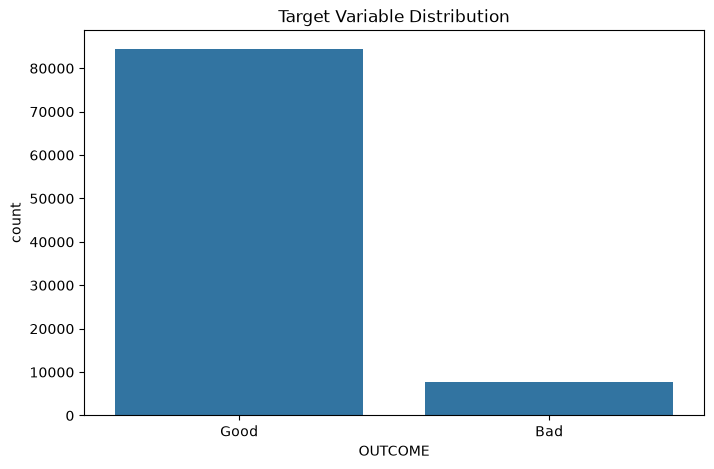

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged_df,
    x="OUTCOME"
)

plt.title("Target Variable Distribution")
plt.show()

### Risk Score Distribution

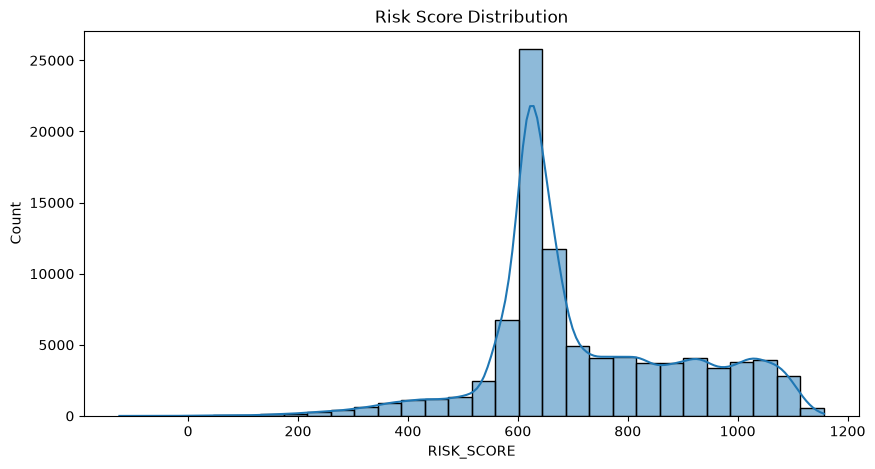

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged_df["RISK_SCORE"],
    bins=30,
    kde=True
)

plt.title("Risk Score Distribution")
plt.show()

### Risk Score vs Outcome :

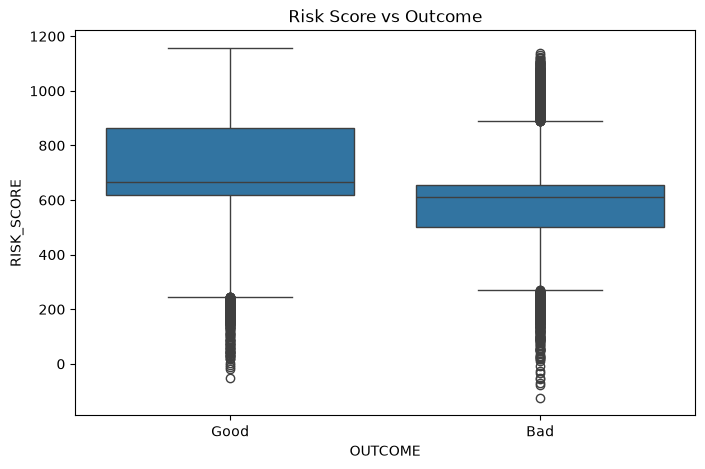

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_df,
    x="OUTCOME",
    y="RISK_SCORE"
)

plt.title("Risk Score vs Outcome")
plt.show()

### Top 20 Important Features :

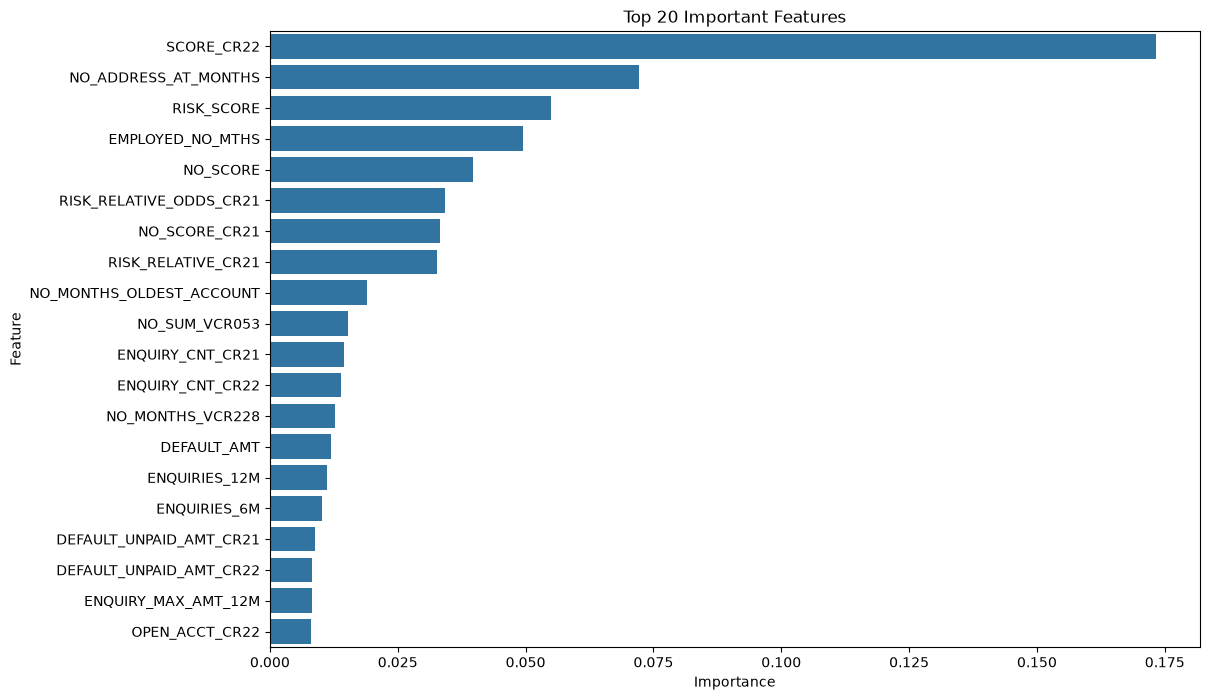

In [45]:
top20 = feature_importance.head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.show()

## Feature Engineering

### Feature Selection

In [31]:
## Random forest classifier



from sklearn.ensemble import RandomForestClassifier


def create_feature_subsets(x, y):

    print("Training Random Forest for Feature Selection...")

    # Train Random Forest
    rf_selector = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf_selector.fit(x, y)

    print("Feature Selection Model Trained Successfully.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": rf_selector.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results = create_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
feature_importance = results["Feature_Importance"]

x_top10 = results["Top10"]

x_top20 = results["Top20"]

x_top30 = results["Top30"]

x_top40 = results["Top40"]

x_top50 = results["Top50"]


# View Top Features
print("\nTop 20 Important Features")
print(feature_importance.head(20))


# Verify Shapes
print("\nDataset Shapes")

print("Top 10 :", x_top10.shape)

print("Top 20 :", x_top20.shape)

print("Top 30 :", x_top30.shape)

print("Top 40 :", x_top40.shape)

print("Top 50 :", x_top50.shape)



Training Random Forest for Feature Selection...
Feature Selection Model Trained Successfully.

Top 20 Important Features
                     Feature  Importance
0                 SCORE_CR22    0.173210
1       NO_ADDRESS_AT_MONTHS    0.072166
2                 RISK_SCORE    0.054873
3           EMPLOYED_NO_MTHS    0.049399
4                   NO_SCORE    0.039779
5    RISK_RELATIVE_ODDS_CR21    0.034273
6              NO_SCORE_CR21    0.033200
7         RISK_RELATIVE_CR21    0.032606
8   NO_MONTHS_OLDEST_ACCOUNT    0.018970
9              NO_SUM_VCR053    0.015299
10          ENQUIRY_CNT_CR21    0.014444
11          ENQUIRY_CNT_CR22    0.013887
12          NO_MONTHS_VCR228    0.012708
13               DEFAULT_AMT    0.011902
14             ENQUIRIES_12M    0.011167
15              ENQUIRIES_6M    0.010222
16   DEFAULT_UNPAID_AMT_CR21    0.008891
17   DEFAULT_UNPAID_AMT_CR22    0.008307
18       ENQUIRY_MAX_AMT_12M    0.008295
19            OPEN_ACCT_CR22    0.007984

Dataset Shapes
To

In [32]:

# Mutual Information Feature Selection..


from sklearn.feature_selection import mutual_info_classif


def create_mi_feature_subsets(x, y):

    print("Calculating Mutual Information Scores...")

    # Calculate MI Scores
    mi_scores = mutual_info_classif(
        x,
        y,
        random_state=42
    )

    print("Mutual Information Calculation Completed.")

    # Create Importance DataFrame
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": mi_scores
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results_mi = create_mi_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
mi_feature_importance = results_mi["Feature_Importance"]

x_top10_mi = results_mi["Top10"]

x_top20_mi = results_mi["Top20"]

x_top30_mi = results_mi["Top30"]

x_top40_mi = results_mi["Top40"]

x_top50_mi = results_mi["Top50"]


# View Top Features
print("\nTop 20 Mutual Information Features")
print(mi_feature_importance.head(20))


# Verify Shapes
print("\nDataset Shapes")

print("Top 10 :", x_top10_mi.shape)

print("Top 20 :", x_top20_mi.shape)

print("Top 30 :", x_top30_mi.shape)

print("Top 40 :", x_top40_mi.shape)

print("Top 50 :", x_top50_mi.shape)

Calculating Mutual Information Scores...
Mutual Information Calculation Completed.

Top 20 Mutual Information Features
                                       Feature  Importance
0                                   SCORE_CR22    0.030034
1                                   RISK_SCORE    0.028793
2                           RISK_RELATIVE_CR21    0.026405
3                                     NO_SCORE    0.025810
4                      RISK_RELATIVE_ODDS_CR21    0.025422
5                                NO_SCORE_CR21    0.024626
6                           NO_STATUS_VCR183_-    0.020931
7                          ENQUIRY_CNT_3M_CR22    0.019903
8                   DOC_TYPE_AU Driver Licence    0.017446
9                                 DEROGATORIES    0.017117
10                         ENQUIRY_CNT_6M_CR22    0.016959
11                           EMPLOYED_STATUS_E    0.016572
12  LICENCE_AVAILABLE_Driver Licence Check Yes    0.016456
13                      CD_STS_RESIDENTIAL_y_R    0.016

In [33]:
#XGBoost Feature Selection

from xgboost import XGBClassifier


def create_xgb_feature_subsets(x, y):

    print("Training XGBoost for Feature Selection...")

    xgb_selector = XGBClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )

    xgb_selector.fit(x, y)

    print("XGBoost Feature Selection Completed.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": xgb_selector.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)

    # Create Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    # Create Feature Subsets
    x_top10 = x[top_10_features]

    x_top20 = x[top_20_features]

    x_top30 = x[top_30_features]

    x_top40 = x[top_40_features]

    x_top50 = x[top_50_features]

    return {
        "Feature_Importance": feature_importance,
        "Top10": x_top10,
        "Top20": x_top20,
        "Top30": x_top30,
        "Top40": x_top40,
        "Top50": x_top50
    }


# Run Feature Selection
results_xgb = create_xgb_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
xgb_feature_importance = results_xgb["Feature_Importance"]

x_top10_xgb = results_xgb["Top10"]

x_top20_xgb = results_xgb["Top20"]

x_top30_xgb = results_xgb["Top30"]

x_top40_xgb = results_xgb["Top40"]

x_top50_xgb = results_xgb["Top50"]

# View Results
print("\nTop 20 XGBoost Features")
print(xgb_feature_importance.head(20))

print("\nDataset Shapes")
print("Top10 :", x_top10_xgb.shape)
print("Top20 :", x_top20_xgb.shape)
print("Top30 :", x_top30_xgb.shape)
print("Top40 :", x_top40_xgb.shape)
print("Top50 :", x_top50_xgb.shape)

Training XGBoost for Feature Selection...
XGBoost Feature Selection Completed.

Top 20 XGBoost Features
                                       Feature  Importance
0                                   RISK_SCORE    0.046752
1                   DOC_TYPE_AU Driver Licence    0.025826
2                                   SCORE_CR22    0.021390
3                                  DEFAULT_AMT    0.017900
4                             SCORECARD_HSHSOL    0.017743
5                         DOC_TYPE_AU Passport    0.017401
6                            SCORE_BAND_CR22_H    0.015541
7                            EMPLOYED_STATUS_U    0.015399
8                       CD_STS_RESIDENTIAL_x_L    0.013932
9                              CD_OCCUPATION_E    0.012775
10                             CD_STS_VCR184_4    0.012614
11             DOC_TYPE_Intl Passport and Visa    0.012089
12                      DOC_TYPE_HAAU 18+ Card    0.012005
13  LICENCE_AVAILABLE_Driver Licence Check Yes    0.011477
14         

In [34]:

# RFE (Recursive Feature Elimination) Feature Selection

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression


def create_rfe_feature_subsets(x, y):

    print("Running Recursive Feature Elimination...")

    base_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

    selector = RFE(
        estimator=base_model,
        n_features_to_select=50,
        step=5
    )

    selector.fit(x, y)

    print("RFE Completed Successfully.")

    feature_ranking = pd.DataFrame({
        "Feature": x.columns,
        "Rank": selector.ranking_
    })

    feature_ranking = (
        feature_ranking
        .sort_values(
            by="Rank",
            ascending=True
        )
        .reset_index(drop=True)
    )

    # Create Feature Lists
    top_10_features = (
        feature_ranking
        .head(10)["Feature"]
        .tolist()
    )

    top_20_features = (
        feature_ranking
        .head(20)["Feature"]
        .tolist()
    )

    top_30_features = (
        feature_ranking
        .head(30)["Feature"]
        .tolist()
    )

    top_40_features = (
        feature_ranking
        .head(40)["Feature"]
        .tolist()
    )

    top_50_features = (
        feature_ranking
        .head(50)["Feature"]
        .tolist()
    )

    return {
        "Feature_Ranking": feature_ranking,
        "Top10": x[top_10_features],
        "Top20": x[top_20_features],
        "Top30": x[top_30_features],
        "Top40": x[top_40_features],
        "Top50": x[top_50_features]
    }


# Run RFE
results_rfe = create_rfe_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
rfe_feature_ranking = results_rfe["Feature_Ranking"]

x_top10_rfe = results_rfe["Top10"]

x_top20_rfe = results_rfe["Top20"]

x_top30_rfe = results_rfe["Top30"]

x_top40_rfe = results_rfe["Top40"]

x_top50_rfe = results_rfe["Top50"]

# View Results
print("\nTop 20 RFE Features")
print(rfe_feature_ranking.head(20))

print("\nDataset Shapes")

print("Top10 :", x_top10_rfe.shape)
print("Top20 :", x_top20_rfe.shape)
print("Top30 :", x_top30_rfe.shape)
print("Top40 :", x_top40_rfe.shape)
print("Top50 :", x_top50_rfe.shape)
rfe_feature_ranking.head(20)

Running Recursive Feature Elimination...


d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
d:\Anaconda\envs\baddebtenv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Plea

RFE Completed Successfully.

Top 20 RFE Features
                                 Feature  Rank
0                           ENQUIRIES_6M     1
1                           DEROGATORIES     1
2                     PERSONAL_LOAN_CR22     1
3                       DEFAULT_CNT_CR22     1
4                   DEFAULT_CNT_12M_CR22     1
5                       DEFAULT_CNT_CR21     1
6                    DEFAULT_CNT_3M_CR22     1
7                             TELCO_CR21     1
8                        CD_OCCUPATION_S     1
9                      RESIDENTIAL_Owned     1
10                    RESIDENTIAL_Rented     1
11  BUREAU_DEFAULT_Default Current1-1000     1
12                    NO_STATUS_VCR183_-     1
13                      SCORECARD_HSHSOL     1
14                       CD_STS_VCR184_2     1
15                       CD_STS_VCR184_1     1
16          CD_STS_RESIDENTIAL_x_Missing     1
17                CD_STS_RESIDENTIAL_x_R     1
18                    NO_STATUS_VCR183_2     1
19         

,Feature,Rank
0,ENQUIRIES_6M,1
1,DEROGATORIES,1
2,PERSONAL_LOAN_CR22,1
3,DEFAULT_CNT_CR22,1
4,DEFAULT_CNT_12M_CR22,1
5,DEFAULT_CNT_CR21,1
6,DEFAULT_CNT_3M_CR22,1
7,TELCO_CR21,1
8,CD_OCCUPATION_S,1
9,RESIDENTIAL_Owned,1


In [35]:
#LightGBM Feature Importance.

from lightgbm import LGBMClassifier


def create_lgbm_feature_subsets(x, y):

    print("Training LightGBM for Feature Selection...")

    lgbm_selector = LGBMClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgbm_selector.fit(x, y)

    print("LightGBM Feature Selection Completed.")

    # Feature Importance
    feature_importance = pd.DataFrame({
        "Feature": x.columns,
        "Importance": lgbm_selector.feature_importances_
    })

    feature_importance = (
        feature_importance
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    # Top Feature Lists
    top_10_features = feature_importance.head(10)["Feature"].tolist()

    top_20_features = feature_importance.head(20)["Feature"].tolist()

    top_30_features = feature_importance.head(30)["Feature"].tolist()

    top_40_features = feature_importance.head(40)["Feature"].tolist()

    top_50_features = feature_importance.head(50)["Feature"].tolist()

    return {
        "Feature_Importance": feature_importance,
        "Top10": x[top_10_features],
        "Top20": x[top_20_features],
        "Top30": x[top_30_features],
        "Top40": x[top_40_features],
        "Top50": x[top_50_features]
    }


# Run Feature Selection
results_lgbm = create_lgbm_feature_subsets(
    x_encoded,
    y
)

# Extract Outputs
lgbm_feature_importance = results_lgbm["Feature_Importance"]

x_top10_lgbm = results_lgbm["Top10"]

x_top20_lgbm = results_lgbm["Top20"]

x_top30_lgbm = results_lgbm["Top30"]

x_top40_lgbm = results_lgbm["Top40"]

x_top50_lgbm = results_lgbm["Top50"]

# View Results
print("\nTop 20 LightGBM Features")
print(lgbm_feature_importance.head(20))

print("\nDataset Shapes")

print("Top10 :", x_top10_lgbm.shape)
print("Top20 :", x_top20_lgbm.shape)
print("Top30 :", x_top30_lgbm.shape)
print("Top40 :", x_top40_lgbm.shape)
print("Top50 :", x_top50_lgbm.shape)

Training LightGBM for Feature Selection...
LightGBM Feature Selection Completed.

Top 20 LightGBM Features
                     Feature  Importance
0                 SCORE_CR22         251
1                   NO_SCORE         194
2       NO_ADDRESS_AT_MONTHS         189
3                 RISK_SCORE         182
4   NO_MONTHS_OLDEST_ACCOUNT         142
5           EMPLOYED_NO_MTHS         126
6              NO_SCORE_CR21         109
7              NO_SUM_VCR053          84
8        ENQUIRY_MAX_AMT_12M          74
9           ENQUIRY_CNT_CR22          71
10          ENQUIRY_CNT_CR21          66
11        ENQUIRY_MAX_AMT_3M          52
12              ENQUIRIES_6M          46
13      CREDIT_CARD_AMT_CR22          43
14   DEFAULT_UNPAID_AMT_CR22          42
15          CLOSED_ACCT_CR21          38
16                  WORST_6M          36
17          NO_MONTHS_VCR228          35
18            OPEN_ACCT_CR22          34
19                TELCO_CR21          34

Dataset Shapes
Top10 : (92115, 

In [36]:
# save the feature engineering features.
'''                                                 # Commenting this module because if i run again it shows error.
feature_importance.to_csv(
    "RandomForest_Feature_Importance.csv",
    index=False
)

mi_feature_importance.to_csv(
    "MutualInformation_Feature_Importance.csv",
    index=False
)

xgb_feature_importance.to_csv(
    "XGBoost_Feature_Importance.csv",
    index=False
)

rfe_feature_ranking.to_csv(
    "RFE_Feature_Ranking.csv",
    index=False
)

lgbm_feature_importance.to_csv(
    "LightGBM_Feature_Importance.csv",
    index=False
) 

x_encoded.to_csv(
    "feature_engineered_dataset.csv",
    index=False
)
 '''  

'                                                 # Commenting this module because if i run again it shows error.\nfeature_importance.to_csv(\n    "RandomForest_Feature_Importance.csv",\n    index=False\n)\n\nmi_feature_importance.to_csv(\n    "MutualInformation_Feature_Importance.csv",\n    index=False\n)\n\nxgb_feature_importance.to_csv(\n    "XGBoost_Feature_Importance.csv",\n    index=False\n)\n\nrfe_feature_ranking.to_csv(\n    "RFE_Feature_Ranking.csv",\n    index=False\n)\n\nlgbm_feature_importance.to_csv(\n    "LightGBM_Feature_Importance.csv",\n    index=False\n) \n\nx_encoded.to_csv(\n    "feature_engineered_dataset.csv",\n    index=False\n)\n '

In [51]:
#Lowest Importance
feature_importance.tail(10)

,Feature,Importance
156,SCORECARD_CR21_INSLV,0.000129
157,DOC_TYPE_Defence Force ID(picture card),0.000122
158,CD_STS_VCR184_X,0.000076
159,NO_STATUS_VCR183_X,0.000061
160,CREDIT_CARD_CR21,0.000049
161,NO_STATUS_VCR183_H,0.000029
162,CD_STS_VCR184_H,0.000028
163,CD_STS_VCR184_6,0.000020
164,DEFAULT_CNT_3M_CR21,0.000004
165,CREDIT_CARD_AMT_CR21,0.000000


In [52]:
# Highest Importance
feature_importance.head(10)

,Feature,Importance
0,SCORE_CR22,0.173210
1,NO_ADDRESS_AT_MONTHS,0.072166
2,RISK_SCORE,0.054873
3,EMPLOYED_NO_MTHS,0.049399
4,NO_SCORE,0.039779
5,RISK_RELATIVE_ODDS_CR21,0.034273
6,NO_SCORE_CR21,0.033200
7,RISK_RELATIVE_CR21,0.032606
8,NO_MONTHS_OLDEST_ACCOUNT,0.018970
9,NO_SUM_VCR053,0.015299
